# Constrained and multi-objective optimization

Real optimization problems rarely have a single clean objective over a box. Two ubiquitous complications, both supported by `mixle.doe`: constraints (regions of the input space are infeasible - unsafe, over-budget, physically impossible) handled by constrained Bayesian optimization, and competing objectives (cost vs quality, speed vs accuracy) handled by multi-objective optimization that maps the Pareto front of best-possible trade-offs.


## Constrained acquisition and Pareto optimality

Real optimization rarely has a single unconstrained objective. Two extensions cover most cases.

Constrained Bayesian optimization. With an unknown feasibility constraint $c(x)\le 0$, model $c$ with its
own GP and weight the acquisition by the posterior probability of feasibility,
$\mathrm{EIC}(x)=\mathrm{EI}(x)\cdot P(c(x)\le 0)$. Infeasible regions are down-weighted automatically,
and as the constraint GP sharpens, the search concentrates on the feasible optimum. Optimizing without
the constraint and rejecting afterward fails, because the unconstrained optimum is often infeasible (this
notebook shows exactly that).

Definition (Pareto dominance and front). For objectives $f_1,\dots,f_m$ to minimize, point $a$ dominates
$b$ if $f_j(a)\le f_j(b)$ for all $j$ with strict inequality somewhere. The Pareto front is the set of
non-dominated points: those for which no objective can improve without another worsening. Multi-objective
optimization seeks to map this front, not a single point.

Definition (hypervolume indicator). Relative to a reference point, the hypervolume is the volume of the
region dominated by the current set of points. It is maximized exactly by the true Pareto front, so it is
the standard scalar quality measure, and expected hypervolume improvement is the multi-objective analogue
of EI.

## Why weighted-sum scalarization is not enough

A tempting shortcut is to collapse the objectives into one weighted sum $\sum_j w_j f_j$ and optimize that
for various weights, tracing out the front.

Theorem (scalarization misses concave fronts). Minimizing a weighted sum $\sum_j w_j f_j$ with $w_j\ge 0$
returns a point on the convex hull of the Pareto front. If part of the front is concave (non-convex),
no choice of nonnegative weights ever selects a point there: those Pareto-optimal trade-offs are
unreachable by weighted-sum scalarization.

Proof idea. A weighted-sum optimum is a point where a supporting hyperplane with normal $w$ touches the
attainable objective set. Supporting hyperplanes only touch the boundary of the convex hull, so points in
a concave indentation of the front, which lie strictly inside that hull, are never optimal for any $w$.
$\quad\blacksquare$

This is why dedicated multi-objective methods (ParEGO with augmented Chebyshev scalarizations, or
expected hypervolume improvement) are needed: they can reach the entire front, concave parts included,
whereas a plain weighted sum cannot. The Pareto-front computation in this notebook recovers the full
front rather than a convex slice of it.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.doe import constrained_minimize, multi_minimize, pareto_mask
rng = np.random.RandomState(0)

## 1. Constrained Bayesian optimization

Suppose the unconstrained optimum sits in a forbidden region (a setting that melts the reactor, blows the budget, violates a spec). We have a black-box objective and black-box constraints $c_k(x)\le 0$. Constrained BO fits a surrogate to the objective and to each constraint, and multiplies the acquisition by the probability of feasibility $\prod_k P(c_k(x)\le 0)$ - so it only spends evaluations where it both expects improvement and believes the point is feasible. We minimize a function whose true optimum is cut off by a linear constraint.


best feasible point: [0.512 0.488]   objective=0.245   x+y=1.000 (<=1 feasible)


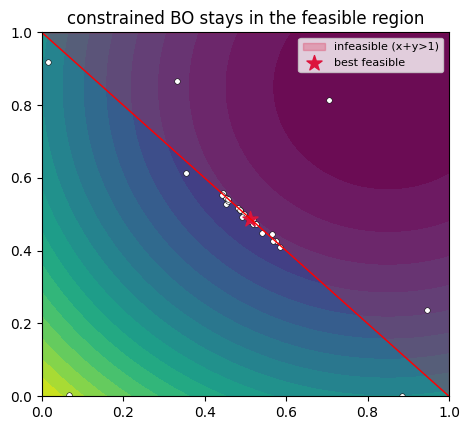

In [2]:
# objective minimized near (0.85, 0.85), but the constraint x+y <= 1 forbids that corner
objective = lambda p: float((p[0] - 0.85) ** 2 + (p[1] - 0.85) ** 2)
constraint = lambda p: float(p[0] + p[1] - 1.0)            # feasible where <= 0
space = [(0.0, 1.0), (0.0, 1.0)]
res = constrained_minimize(objective, [constraint], space, n_init=6, n_iter=24, seed=1)
print('best feasible point: %s   objective=%.3f   x+y=%.3f (<=1 feasible)' %
      (np.round(res.best_x, 3), res.best_y, res.best_x.sum()))

fig, ax = plt.subplots(figsize=(4.8, 4.4))
gx = np.linspace(0, 1, 100); G = np.array([[objective((a, b)) for a in gx] for b in gx])
ax.contourf(gx, gx, G, levels=20, cmap='viridis')
ax.fill_between([0, 1], [1, 0], 1, color='crimson', alpha=0.25, label='infeasible (x+y>1)')
ax.scatter(res.x[:, 0], res.x[:, 1], c='white', s=16, edgecolors='k', lw=0.4)
ax.scatter(*res.best_x, c='crimson', s=130, marker='*', label='best feasible')
ax.plot([0, 1], [1, 0], 'r-', lw=1); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('constrained BO stays in the feasible region'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Multi-objective optimization and the Pareto front

When two objectives compete (you can't minimize both at once), there is no single best point - there is a Pareto front of non-dominated trade-offs (you can't improve one objective without worsening the other). `multi_minimize` uses ParEGO (random augmented-Tchebycheff scalarizations + GP-EI) to map that front in few evaluations. We optimize two competing objectives and plot the recovered front in objective space.


evaluated 35 points; 24 are Pareto-optimal


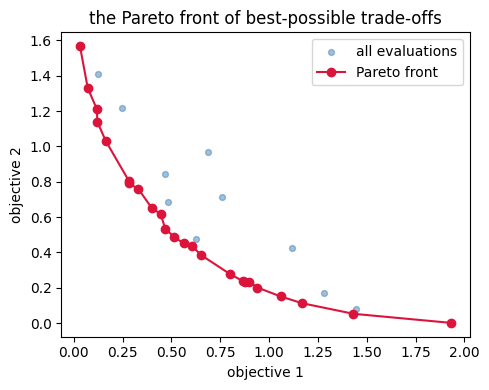

In [3]:
# two competing objectives over a 2-D input: pull toward opposite corners a and b
a, b = np.array([0.0, 0.0]), np.array([1.0, 1.0])
f1 = lambda p: float(np.sum((np.asarray(p) - a) ** 2))
f2 = lambda p: float(np.sum((np.asarray(p) - b) ** 2))
res = multi_minimize([f1, f2], [(0.0, 1.0), (0.0, 1.0)], n_init=10, n_iter=25, seed=1)
front = res.pareto_y                                       # non-dominated objective vectors
print('evaluated %d points; %d are Pareto-optimal' % (len(res.y), len(front)))

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(res.y[:, 0], res.y[:, 1], s=18, color='steelblue', alpha=0.5, label='all evaluations')
order = np.argsort(front[:, 0])
ax.plot(front[order, 0], front[order, 1], 'o-', color='crimson', label='Pareto front')
ax.set_xlabel('objective 1'); ax.set_ylabel('objective 2'); ax.legend()
ax.set_title('the Pareto front of best-possible trade-offs')
plt.tight_layout(); plt.show()

## 3. Why the constraint must be in the optimizer

It is tempting to optimize ignoring the constraint and just reject infeasible answers - but the unconstrained optimum often is infeasible, so you get nothing usable. We run a plain (unconstrained) BO on the same objective and show its best point violates $x+y\le 1$, whereas constrained BO (§1) returned a feasible optimum.


In [4]:
from mixle.doe import minimize
c_res = constrained_minimize(objective, [constraint], space, n_init=6, n_iter=24, seed=1)
u = minimize(objective, space, n_init=6, n_iter=24, seed=1)
print('unconstrained BO  best x+y = %.2f  -> feasible? %s' % (u.best_x.sum(), bool(u.best_x.sum() <= 1.0 + 1e-6)))
print('constrained BO    best x+y = %.2f  -> feasible? %s' % (c_res.best_x.sum(), bool(c_res.best_x.sum() <= 1.0 + 1e-6)))
print('ignoring the constraint and rejecting afterward would discard the best point and waste the budget.')

unconstrained BO  best x+y = 1.70  -> feasible? False
constrained BO    best x+y = 1.00  -> feasible? True
ignoring the constraint and rejecting afterward would discard the best point and waste the budget.


## References

- Gardner, J. R. et al. (2014). Bayesian optimization with inequality constraints (https://proceedings.mlr.press/v32/gardner14.html). ICML. - feasibility-weighted acquisition.
- Gelbart, M. A., Snoek, J. & Adams, R. P. (2014). Bayesian optimization with unknown constraints (https://arxiv.org/abs/1403.5607). UAI.
- Knowles, J. (2006). ParEGO: a hybrid algorithm with on-line landscape approximation for expensive multiobjective optimization (https://doi.org/10.1109/TEVC.2005.851274). IEEE Trans. Evol. Comput. 10(1), 50-66.
- Emmerich, M., Giannakoglou, K. & Naujoks, B. (2006). Single- and multiobjective evolutionary optimization assisted by Gaussian random field metamodels (https://doi.org/10.1109/TEVC.2005.859463). IEEE Trans. Evol. Comput. 10(4), 421-439. - expected hypervolume improvement.
- Deb, K. (2001). Multi-Objective Optimization using Evolutionary Algorithms. Wiley.


## Exercises and extensions

1. Tighter and multiple constraints. Shrink the feasible region and add a second black-box constraint; show constrained BO (Gardner et al.) respects both, and study how early evaluations are spent probing the feasibility boundary vs the objective.
2. Hypervolume, the right MO metric. Implement the hypervolume indicator of a Pareto front (Emmerich et al.) and use it to track convergence of `multi_minimize` over iterations; compare ParEGO (Knowles) to a random-scalarization baseline and to NSGA-II on the same budget.
3. Reading the front for decisions. From a recovered Pareto front, compute the knee point (best-balanced trade-off) and the extremes; map each to a concrete decision and discuss how a stakeholder's utility selects a point on the front (Deb).
4. Scalarization spread. Vary ParEGO's `rho` and iteration count and measure how uniformly the front gets covered (a spacing/spread metric); find settings that avoid clustering at the extremes.
